# Library imports

In [1]:
# Multiprocessing specific : 
from multiprocessing import Pool
import os
from functools import partial
from tqdm.notebook import tqdm

# Regular libraries : 
import pandas as pd
import numpy as np
from math import radians,atan2,sin,cos,acos,asin,pi,acos,sqrt,ceil,atan
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import timeit

# HurrSim library tools
from hurrSim.post_processing import approaching_hurr2MP
from hurrSim import post_processing

#
from scipy.optimize import minimize,fsolve
from scipy.stats import weibull_min, genextreme
from scipy import stats
import statsmodels.api as sm

# Check if coordinate is land ?
import shapely.geometry as sgeom
import cartopy.io.shapereader as shpreader
from shapely.ops import unary_union
from shapely.prepared import prep

In [2]:
def bearing(y1,x1,y2,x2): 
    """"
    Returns the bearing angle (North = 0), positive counter clockwise. Converts data to rad and outputs 
    bearing angle in rad.
    """
    rady1 = radians(y1) 
    radx1 = radians(x1)
    rady2 = radians(y2)
    radx2 = radians(x2)
    
    y = sin(radx2-radx1) * cos(rady2)
    x = cos(rady1) * sin(rady2) - sin(rady1) * cos(rady2) * cos(radx2-radx1)
    bearing_angle = atan2(y,x)
    return bearing_angle

def haversine_distance(y1,x1,y2,x2,R=6372.8*1000) :
    """
    Find the true distance between two points in spherical coordinates.
    """
    dLat = radians(y2 - y1)
    dLon = radians(x2 - x1)
    lat1 = radians(y1)
    lat2 = radians(y2)

    a = sin(dLat/2)**2 + cos(lat1)*cos(lat2)*sin(dLon/2)**2
    c = 2*asin(sqrt(a))
    return R * c
    
def min_geodesic_dist(p1,p2,p3,R = 6372.8*1) :
    
    """
    Returns the shortest arc distance (in km by default) between a geodesic (arc on a sphere generating a great arc circle) 
    and a point on the sphere.
    To do so, it analyses 3 cases : 
    (1) : The point yields an obtuse angle versus plane created by the geodesic the first dataset ;
    (2) : The point yields an acute angle and is somewhere between the two points defining the geodesic plane ;
    (3) : The point yields an acute angle but is beyond the 2nd point defining the geodesic plane.
    
    p1 : Coordinate 1 (base value for geodesic), using (lat,long) format.
    p2 : Coordinate 2 (second value for geodesic), using (lat,long) format.
    p3 : Coordinate 3 (the point), using (lat,long) format.
    
    R = 6372.8*1000  # Earth's radius. 
    
    Credits for inspiration and taken from : 
    http://www.movable-type.co.uk/scripts/latlong.html
    https://stackoverflow.com/questions/20231258/minimum-distance-between-a-point-and-a-line-in-latitude-longitude?noredirect=1&lq=1
    https://stackoverflow.com/questions/32771458/distance-from-lat-lng-point-to-minor-arc-segment
    
    """    
    # Step 1 : Find bearing A to C 
    bearingAC = bearing(p1[0],p1[1],p3[0],p3[1])
    # Step 2 : Find bearing A to B
    bearingAB = bearing(p1[0],p1[1],p2[0],p2[1])   
    # Distance A to C : 
    distanceAC = haversine_distance(p1[0],p1[1],p3[0],p3[1],R)
    
    
    #print(f'Bearing AC is:{bearingAC*(360/(2*pi))}')
    #print(f'Bearing AB is :{bearingAB*(360/(2*pi))}')
    #print(f'The AC distance is :{distanceAC}')
    
    # Angular difference : 
    diff = abs(bearingAC-bearingAB)
    #print(f'The bearing diff is :{diff*(360/(2*pi))}')
    if diff > pi :
        diff = 2*pi-diff
        #print(f'After correction:{diff*(360/(2*pi))}')
        
    # Select between the three cases : 
    # Case 1 : the angle is checked at point A and is obtuse, the cross-track distance yields a distance 
    # which is out of the bounds AB :
    if diff > pi/2 : 
        dxa = distanceAC
        along_path_ratio = 0
    # Case 2 & 3 : the angle is acute, thus the point projects either on the geodesic AB or beyond :
    else :
        # 1st : Compute distance between point and great-circle path :
        dxt = asin(sin(distanceAC/R)*sin(bearingAC-bearingAB))*R
        # 2nd : Compute distance between 2 start and end point of the great-circle path : 
        distanceAB = haversine_distance(p1[0],p1[1],p2[0],p2[1],R)       
        # 3rd : Compute the along-track distance from point A to find how far from A the point C lands on the great-circle.
        distanceAC_along = acos(cos(distanceAC/R) / cos(dxt/R) )*R
        
    # Case 2 : the point projects on the geodesic AB : 
        if distanceAC_along> distanceAB :
            dxa = haversine_distance(p2[0],p2[1],p3[0],p3[1])
            along_path_ratio = 1
    # Case 3 : the point projects beyond the geodesic AB : 
        else : 
            dxa = abs(dxt)
            along_path_ratio = distanceAC_along/distanceAB
    return dxa, along_path_ratio

def haversine_destination(lat_i,long_i,theta_ip1,dist, R = 6372.8*1000) :
    """
    Calculate final coordinates based on initial coordinates, initial bearing and speed
    All inputs in degrees. Unless specified, R is 6372.8 km (earth's radius, converted to meters).
    All outputs in degrees.
    
    See : 
    http://www.movable-type.co.uk/scripts/latlong.html

    """
    # Distance, relative to the earth's radius : 
    d_r = (dist/R)

    # Converting to radians : 
    lat_i_rad = radians(lat_i)
    long_i_rad = radians(long_i)
    theta_ip1_rad = radians((theta_ip1)) 

    # New latitude (in radians) :
    lat_p1 = (asin(sin(lat_i_rad)*cos(d_r)
                  +cos(lat_i_rad)*sin(d_r)*cos(theta_ip1_rad)))
    # New longitude (in radians) : 
    long_p1 = (long_i_rad + 
        atan2(sin(theta_ip1_rad)* sin(d_r) * cos(lat_i_rad),cos(d_r)-sin(lat_i_rad)*sin(lat_p1)))

    # Output everything as degrees : 
    return(lat_p1*(360/(2*np.pi)),long_p1*(360/(2*np.pi)))

def V_grad(c,alpha,r,B,pc,RMW,lat,rho = 1.15) : 
    """
    c     = Eye of the storm translation speed m/s
    alpha = relative angle between hurricane heading and coordinate of interest (degree)
    r     = distance between eye of the storm and coordinate of interest (m)
    B     = Holland B parameter (pressure profile parameter)
    pc    = pressure deficit at the eye of the storm (in milibar)
    RMW   = Storms radius of maximum wind (km)
    lat   = latitude (degree)
    rho   = 1.2 kg/m3
    """    
    
    if lat > 40 : 
        pc = pc-40
    
    # Adjust the variables : 
    alpha = alpha*np.pi/180 # converting degrees to radians
    lat   = lat*np.pi/180   # converting degrees to radians
    delta_p = 1013-pc
    RMW = RMW*1000          # converting km to m
    f = 2*(2*np.pi/(3600*23+56*60+4.1))*np.sin(lat)  # Coriolis frequency   (rad/sec)  

    
    # Compute the gradient wind speed :
    V = 1/2*(c*sin(alpha)-f*r)+sqrt(1/4*((c*sin(alpha)-f*r)**2)+100*B*delta_p/rho*((RMW/r)**B)*np.exp(-((RMW/r)**B))) 
    
    #V = 1/2*(c*sin(alpha)-f*r)+sqrt(1/4*((c*sin(alpha)-f*r)**2)+100*B*delta_p/rho*((RMW/r)**B)*np.exp(-((RMW/r)**B)))
    #V = 1/2*(c*sin(alpha)-f*r)+sqrt(1/4*((c*sin(alpha)-f*r)**2)+B*delta_p/rho*((RMW/r)**B)*np.exp(-((RMW/r)**B)))
    return V

def lin_interp(a,b,xa,xb,delta): 
    """
    Interpolate linearly taking 'a' as the intercept. 
    """

    c = (b - a) 
    slope = (b-a)/(xb-xa)
    z = a + delta*slope
    return z

# Custom landmap (removing some islands) : 
land_shp_fname = '50m_land_edited.shp'

land_geom = unary_union(list(shpreader.Reader(land_shp_fname).geometries()))
land = prep(land_geom)
def is_land(long, lat):
    """
    Function to assert whether a longitude-latitude pair is overland or at sea.
    """
    return land.contains(sgeom.Point(long, lat))


def find_Uz_land(x,I,V1000,z = 10,z0 = 0.03, k = 0.4, alpha = 0.4, n = 2, K = 75) : 
    """
    The function to minimize if storm is on land 
    z0 = 0.03 m   : Surface roughness on open terrain (see Vickery 2009c)
    z0 = 0.1 : for some reason, previous code used this value (?)
    H_hat         : Gradient wind height (estimated)    
    Cd            : Drag coefficient = k^2 / (ln^2((z/z0)), where k is von karman cste, z = 10 m and z0 = 0.03 m 
    """
    
    # Take Cd 0.0047 (not to force compute at every step)
    #Cd = k**2/(np.log(z/z0)**2) # should equal 0.0047  
    Cd = 0.0047 # Cd 
    
    K = k*z*sqrt(Cd)*(x)   
    H_hat = sqrt(2*K/I)*atan(-1-2/(Cd*V1000*sqrt(2/(K*I))))/1.12 # Boundary layer height

    if H_hat <= 300 : 
        H_hat = 300
    if H_hat >= 1200 : 
        H_hat = 1200      
         
    delta = sqrt(Cd)/k*V1000*(np.log(z/z0)-alpha*(z/H_hat)**n)-x
    return delta

def find_Uz_land2(I,V1000,z2=10,z0=0.03,z1 = 1000,k=0.4,alpha=0.4,n=2) :

    V1000 = V1000*1.15
    Cd = 0.0047 # Cd 
    
    K = k*z*sqrt(Cd)*(x)   
    H_hat = sqrt(2*K/I)*atan(-1-2/(Cd*V1000*sqrt(2/(K*I))))#/1.12 # Boundary layer height

    if H_hat <= 300 : 
        H_hat = 300
    if H_hat >= 1200 : 
        H_hat = 1200  


    frctn_vlcty = V1000*k/(np.log(H_hat/1.12/z0)-alpha*(H_hat/1.12/H_hat)**n)
    u10 = frctn_vlcty/k*(np.log(z2/z0)-alpha*(H_hat/1.12/H_hat)**n)   
        
    #u10 = V1000*(np.log(z2/z0)-alpha*(z2/H_hat)**n)/(np.log(z1/z0)-alpha*(H_hat/H_hat)**n)

    #print(H_hat,u10)
    return [u10,H_hat]



def find_Uz_sea(x,V1000,H_hat,Cdmax,z=10, z0 = 0.0013, k = 0.4, alpha = 0.4, n = 2, K = 75) :
    """
    Function to minimize if storm is at sea
    z0 = 0.0013 m : Surface roughness at sea (see Vickery 2009c)
    H_hat         : Gradient wind height (estimated)
    Cd            : Drag coefficient
    k     = 0.4 # Von kármán constant
    alpha = 0.4 # Constant from Vickery et al 2009
    n     = 2   # Constant from Vickery et al 2009
    K     = 75  # m**2/s ; Turbulent diffusivity of momentum (simplification from Kepert 2001)    
    """ 
      
    Cd = min(((0.49+0.065*x)*(10**(-3))),Cdmax)
    delta = sqrt(min(((0.49+0.065*x)*(10**(-3))),Cdmax))/0.4*V*(np.log(z/0.0013)-0.4*(z/H_hat)**2)-x
   
    return delta   

    
def Vgrad_2_surf(Vg_1200,r,RMW,land_status,lat) : 
    """
    Function converting gradient winds to surface (10m) winds
    
    Vg          = Gradient wind speed (m/s)
    r           = min(radial distance in km from storm center, RMW)
    land_status = define whether land or ocean computation procedure should be taken
    lat         = latitude of the coordinate 
    
    
    """
    solutions = []
    
    lat = lat*np.pi/180

    Vg_1000 = Vg_1200/1.15  # According to Liu 2014 
    # Initialize some parameters : 
    # Coriolis parameter
    f = 2*(2*np.pi/(3600*23+56*60+4.1))*np.sin(lat)  # Coriolis frequency   (rad/sec)     

    # Intertial stability : 
    I = sqrt((f+2*Vg_1000/(r))*(f+Vg_1000/(r)))  # Neglecting the dVg/dr term (Vickery 2009c)   

    # Maximum drag coefficient :
    r_Cd = max(RMW,r)
    
    Cdmax = (0.0881*r_Cd+17.66)*(10**(-4))   # (Vickery 2009c)
    if Cdmax >= 0.0025 : 
        Cdmax = 0.0025
    if Cdmax <= 0.0019 : 
        Cdmax = 0.0019
    
    #Lets solve this equation by finding the roots : 
    
    # Use a first "guess" value as close to zero as possible :
    x1 = 25
    # Use another first "guess" value, this time as reasonably high as possible : 
    x2 = x1+70
    
    # On land : 
    if land_status == True :
        try : 
            s1 = fsolve(find_Uz_land,x0=x1,args = (I,Vg_1000))
            s2 = fsolve(find_Uz_land,x0=x2,args=(I,Vg_1000))
            s = min(s1,s2)          
        except :
            s = fsolve(find_Uz_land,x0=30,args=(I,Vg_1000,Cdmax))

    # At sea : 
    else : 
        # Boundary layer height :
        H_hat = 343.7+0.26/I # in meters. (Vickery 2009c)

        # Bounds for the height :
        if H_hat <= 300 : 
            H_hat = 300
        if H_hat >= 1200 : 
            H_hat = 1200        

        try : 
            s1 = fsolve(find_Uz_sea,x0=x1,args = (Vg_1000,H_hat,Cdmax))
            s2 = fsolve(find_Uz_sea,x0=x2,args=(Vg_1000,H_hat,Cdmax))
            s = min(s1,s2)

        except :
            s = fsolve(find_Uz_sea,x0=30,args=(Vg_1000,H_hat,Cdmax))       
    return s[0]

def V_surfSW(Vg,r,lat,land_status,z = 10) : 
    
    if land_status == True : 
        z0 = 0.03
    else : 
        z0 = 0.0013
    
    # input as km, converted to meter
    r = r*1000
    
    f = 2*(2*np.pi/(3600*23+56*60+4.1))*np.sin(lat)  # Coriolis frequency   (rad/sec)
    
    # Intertial stability : 
    I = sqrt((f+2*Vg/(r))*(f+Vg/(r)))  # Neglecting the dVg/dr term (Vickery 2009c) 
    
    Ros = Vg/(I*z0)
    
    
    # Regression coefficients from Snaiki and Wu 2018
    a = -0.4807
    b = -0.05
    c = 4.0221

    lnd = a*np.log(I)+b*np.log(Ros)+c
    # Height of maximum winds
    d = np.exp(lnd)
    
    # Gradient Wind height
    ref_h = max(1200,d)

    factor1 = (np.log(ref_h/z0)+9.026*sin(ref_h/d)*np.exp(-ref_h/d))
    factor2 = (np.log(z/z0)+9.026*sin(z/d)*np.exp(-z/d))

    Vz = Vg*factor2/factor1
        
    return Vz

## Importing coordinates of interest

In [3]:
# Setting the grid system : 
# Longitude :
min_lat = 10 # degree
max_lat = 60 # degree
lat_grids = 5 # degree

# Latitude : 
min_long = 0 # degree
max_long = 110 # degree
long_grids = 5 # degree

# Grid info
grid_width = max_long-min_long
grid_height = max_lat-min_lat
nb_width_cell = int(grid_width/long_grids)
nb_height_cell = int(grid_height/lat_grids)
nb_cells = int((nb_width_cell)*(nb_height_cell))

long_range = np.linspace(min_long,max_long,int(nb_width_cell+1))
lat_range = np.linspace(min_lat,max_lat,int(nb_height_cell+1))

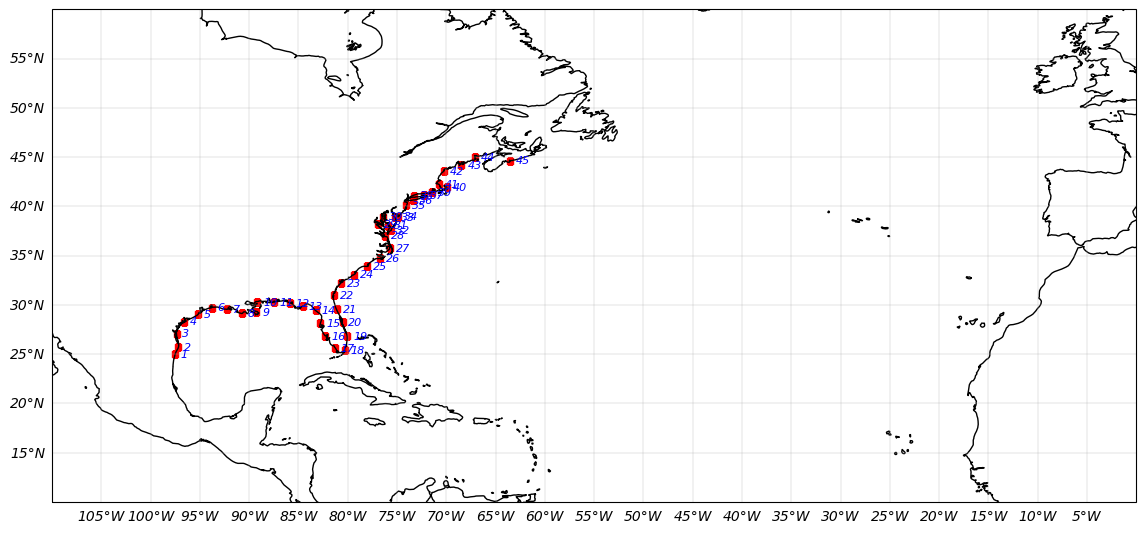

In [4]:
# Dataframe of all coordinates of interest : 
mileposts = pd.read_excel('mileposts.xlsx')

# Limits to which searching for coordinates is not required :  
search_boundaries = (mileposts['Lat'].max()+3,mileposts['Lat'].min()-3,mileposts['Long'].min()-3,mileposts['Long'].max()+3)

# List their individual ids : 
mileposts_ids = mileposts.index.to_list()
milepost_list = [f"Milepost pts {x+1}"for x in mileposts_ids]

# Bit of a visual background information on the mileposts: 
fig_width = 16
fig_height = (4/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))
ax = plt.axes(projection=ccrs.PlateCarree()) 
ax.set_extent([-max_long, min_long, min_lat, max_lat], crs = ccrs.PlateCarree()) 
ax.scatter(mileposts['Long'], mileposts['Lat'], color='red', s=25, marker = 's')
gl = ax.gridlines(xlocs = -long_range, ylocs = lat_range, draw_labels=True,linewidth=0.25)
for row in mileposts.iterrows() : 
    ax.text(row[1]['Long']+0.6, row[1]['Lat']-0.3,f"{row[0]+1}",transform=ccrs.PlateCarree(),size = 8, color = 'b')

gl.top_labels = False
gl.right_labels = False
ax.coastlines()

## Retrieve concatenated storms

In [5]:
reference_folder = r"C:\YOUR\LOCAL\DIRECTORY\TO\STORE\RESULTS"

# The database :
path = os.path.join(reference_folder,"results",'concatenated_jobs.pickle')
hurr_dist_db = pd.read_pickle(path)

# The maximum recorded year : 
max_year_sim = np.load(os.path.join(reference_folder,"results","total_years.npy")).max()

# Some visual informations : 
print(f'The simulation database contains {max_year_sim} years of storms simulated.')
display(hurr_dist_db)

The simulation database contains 10058 years of storms simulated.


,Hurr_ids,time,latitude,longitude,cell_id,c_i,theta_i,land status,invalid sst_status,tag,...,Milepost pts 36,Milepost pts 37,Milepost pts 38,Milepost pts 39,Milepost pts 40,Milepost pts 41,Milepost pts 42,Milepost pts 43,Milepost pts 44,Milepost pts 45
0,Hurr-1-3,1882-09-27 00:00:00,23.379335,-81.394245,50,2.281884,-38.938076,False,False,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Hurr-1-3,1882-09-27 06:00:00,23.752246,-80.192381,50,5.988869,-71.059042,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Hurr-1-3,1882-09-27 12:00:00,24.070625,-79.148548,51,5.180017,-71.337894,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Hurr-2-2,1926-12-03 12:00:00,23.145089,-81.572337,50,7.986946,64.047201,False,False,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hurr-2-2,1926-12-03 18:00:00,24.171991,-82.931402,50,8.309613,50.208860,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445123,Hurr-10058-12,1864-10-25 00:00:00,41.753056,-71.283559,140,14.322215,-28.301635,True,False,1.0,...,"[216.29080335367524, 1]","[108.82817604453608, 1]","[182.6736863416054, 1]","[38.058130075444375, 1]","[76.35108606512141, 1]","[0.322675484209107, 1]","[53.40832601081749, 1]",NaN,NaN,NaN
445124,Hurr-10058-12,1864-10-25 06:00:00,44.027873,-68.865690,141,14.845182,-37.091848,False,False,2.0,...,NaN,NaN,NaN,NaN,"[246.64469829153384, 1]",NaN,"[122.36109563541517, 1]","[4.722107801342649, 1]","[6.17481329714677, 1]",NaN
445125,Hurr-10058-12,1864-10-25 12:00:00,45.138611,-66.638683,163,9.970547,-54.219501,True,False,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[179.45046571640782, 1]","[36.860566908741255, 1]","[179.23019053768823, 1]"
445126,Hurr-10058-12,1864-10-25 18:00:00,46.067144,-64.691137,164,8.490175,-55.034025,True,False,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[219.74424164510975, 1]","[178.9181938399366, 1]"


## Process historical storms (if needed)

In [6]:
# Load the file :
edited_atlantic_storms = pd.read_csv('edited_atlantic_storms.csv')

# If desired, the historical years can be clipped : 
#min_year = 1970 # Satellites begin in 1966 (better reference for storm counts)
min_year = 1850
edited_atlantic_storms['year'] = pd.DatetimeIndex(edited_atlantic_storms['date']).year
edited_atlantic_storms = edited_atlantic_storms[edited_atlantic_storms.year > min_year]

# Display some visuals : 
display(edited_atlantic_storms.head(5))
indiv_hist_hurr = edited_atlantic_storms.groupby(['id'])

,index,id,name,date,record_identifier,status_of_system,latitude,longitude,maximum_sustained_wind_knots,maximum_pressure,...,Int_im2,Int_ip1,SST_p1,ln_Int,ln_Int_im1,ln_Int_im2,ln_Int_ip1,delta_SST,pc_comp,year
0,0,AL011851,UNNAMED,1851-06-25 00:00:00,NaN,HU,28.0,-94.8,80,NaN,...,NaN,0.056702,301.103647,-2.867736,NaN,NaN,-2.869948,-0.067438,974.265295,1851
1,1,AL011851,UNNAMED,1851-06-25 06:00:00,NaN,HU,28.0,-95.4,80,NaN,...,NaN,0.056564,301.029686,-2.869948,-2.867736,NaN,-2.872374,-0.073961,974.265295,1851
2,2,AL011851,UNNAMED,1851-06-25 12:00:00,NaN,HU,28.0,-96.0,80,NaN,...,0.056827,0.056721,300.983856,-2.872374,-2.869948,-2.867736,-2.869614,-0.045830,974.265295,1851
3,3,AL011851,UNNAMED,1851-06-25 18:00:00,NaN,HU,28.1,-96.5,80,NaN,...,0.056702,0.056486,300.983856,-2.869614,-2.872374,-2.869948,-2.873757,0.000000,974.056133,1851
4,4,AL011851,UNNAMED,1851-06-25 21:00:00,L,HU,28.2,-96.8,80,NaN,...,0.056564,NaN,NaN,-2.873757,-2.869614,-2.872374,NaN,NaN,974.237894,1851


In [7]:
# This is a slow process, to avoid repeating it : 
try :
    hist_hurr_dist_db = pd.read_csv('hist_hurr_dist.csv')
except :

    print('Beginning assessment of historical approaching storms...')
    start = timeit.default_timer()

    # Storage variable
    hist_hurr_dist_db = pd.DataFrame()
    #-------------------------------------------
    # Chunking for the cores : 
    # Number of cores available :
    available_cpus = os.cpu_count()-1

    # List the grouping of ids to send for multiprocessing : 
    hist_ids_to_mp = np.array_split(edited_atlantic_storms['id'].unique(),available_cpus*10)

    # Variables to include within the "multiprocessing call" : 
    Sim_args = partial(post_processing.mp_approaching_hurr2MP,   # the function
            hist_ids_to_mp,                                           # Variables required by the function
            indiv_hist_hurr,
            mileposts,
            search_boundaries,
            era = 'Historical'
                      )

    # Launch simulations : 
    if __name__ == "__main__" :
        with Pool(available_cpus) as pool :
            with tqdm(total = edited_atlantic_storms['id'].unique().shape[0], desc='Number of storms successfully processed : ') as pbar1 :
                for processed in pool.imap(Sim_args,range(len(hist_ids_to_mp))) :

                        hist_hurr_dist_db = pd.concat([hist_hurr_dist_db,processed[0]]).sort_index()

                        # Update the progress bar : 
                        pbar1.update(n=processed[1])


    # List the mileposts within the dataframe : 
    milepost_list = [x for x in hist_hurr_dist_db.columns if 'Milepost' in x]  
    # Clear results which never get within 250 km :          
    hist_hurr_dist_db = hist_hurr_dist_db.dropna(subset = milepost_list, how = 'all')

    # Save everything :
    hist_hurr_dist_db.to_csv('hist_hurr_dist.csv',index = False)

    end = timeit.default_timer()   
    print(f'Assessment successfully finished! Elapsed time : {end-start:.2f} seconds')

print(f'The historic datasets contain {edited_atlantic_storms.shape[0]} steps, but only {hist_hurr_dist_db.shape[0]}'
        ' are of interest.')


display(hist_hurr_dist_db.head(5))

The historic datasets contain 52691 steps, but only 7514 are of interest.


,index,id,name,date,record_identifier,status_of_system,latitude,longitude,maximum_sustained_wind_knots,maximum_pressure,...,Milepost pts 36,Milepost pts 37,Milepost pts 38,Milepost pts 39,Milepost pts 40,Milepost pts 41,Milepost pts 42,Milepost pts 43,Milepost pts 44,Milepost pts 45
0,0,AL011851,UNNAMED,1851-06-25 00:00:00,NaN,HU,28.0,-94.8,80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,AL011851,UNNAMED,1851-06-25 06:00:00,NaN,HU,28.0,-95.4,80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,AL011851,UNNAMED,1851-06-25 12:00:00,NaN,HU,28.0,-96.0,80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,AL011851,UNNAMED,1851-06-25 18:00:00,NaN,HU,28.1,-96.5,80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,AL011851,UNNAMED,1851-06-25 21:00:00,L,HU,28.2,-96.8,80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Statistics per milepost

In [8]:
dict_occur = {}
i = 1
for mp in milepost_list :

    # First : copy the dataframe, not to edit the original 
    df1 = hurr_dist_db.copy()
    df2 = hist_hurr_dist_db.copy()
    
    #### List of columns could be extended for future calculations on a "per milepost" basis ###############
    # Then : Slice the df to get only the columns of interest per Hurricane Id, get rid of empty MP rows, then get
    # rid of duplicate records per storm 
    df1 = df1.loc[:,['Hurr_ids','pc','c_i','theta_i',mp]].dropna(subset=mp)
    df1A= df1.drop_duplicates(subset = ['Hurr_ids'],keep = 'first') # occurences
    df1B = df1.groupby('Hurr_ids')['pc'].max()
    df1Bm = df1B.mean()
    df1Bstd = df1B.std()
    
    df1C = df1.groupby('Hurr_ids')['c_i'].max()
    df1Cm = df1C.mean()
    df1Cstd = df1C.std()
    
    df1D = df1.groupby('Hurr_ids')['theta_i'].max()
    df1Dm = df1D.mean()
    df1Dstd = df1D.std()    
    
    df2 = df2.loc[:,['id','maximum_pressure','Vi','theta',mp]].dropna(subset=mp)
    df2A = df2.drop_duplicates(subset = ['id'],keep = 'first') # occurences
    df2B = df2.groupby('id')['maximum_pressure'].max()
    df2Bm= df2B.mean()
    df2Bstd = df2B.std()
    
    df2C = df2.groupby('id')['Vi'].max()
    df2Cm = df2C.mean()
    df2Cstd = df2C.std()
    
    df2D = df2.groupby('id')['theta'].max()
    df2Dm = df2D.mean()
    df2Dstd = df2D.std()       
    
    df3 = hurr_dist_db.copy().loc[:,['Hurr_ids','latitude','longitude','c_i','theta_i','pc','RMW','Holland B','next_latitude','next_longitude','next_c_i','next_theta_i','next_pc','next_RMW','next_Holland B',mp]].dropna(subset=mp)  
    
    dict_occur[f'MP{i}'] = [df1A,df1A.shape[0],df1Bm,df1Bstd,df1Cm,df1Cstd,df1Dm,df1Dstd,
                            df2A,df2A.shape[0],df2Bm,df2Bstd,df2Cm,df2Cstd,df2Dm,df2Dstd,
                            df3
                           ]
        
    i+=1

# Sample output from the dictionnary of occurences : 
print(f'At milepost 3, the number of storms is : {dict_occur["MP3"][1]}. The complete record is : ')
display(dict_occur['MP3'][0])

At milepost 3, the number of storms is : 7084. The complete record is : 


,Hurr_ids,pc,c_i,theta_i,Milepost pts 3
15,Hurr-2-2,1012.898643,5.224087,-102.657101,"[241.08204117236346, 1]"
34,Hurr-4-1,999.208761,2.036428,83.990940,"[33.84933361754782, 1]"
97,Hurr-4-5,981.047244,3.641681,107.750641,"[237.35710187531447, 1]"
118,Hurr-5-1,917.151346,4.405695,92.512220,"[179.47037176044253, 1]"
156,Hurr-5-17,1011.939868,8.819442,-140.221711,"[174.9026992153773, 1]"
...,...,...,...,...,...
444723,Hurr-10049-12,908.789283,8.267594,55.782846,"[221.53285655832386, 1]"
444759,Hurr-10050-7,1012.000000,1.475230,62.424117,"[126.25620533699144, 1]"
444926,Hurr-10052-33,1012.446386,40.495768,163.807612,"[153.86894690264683, 1]"
445036,Hurr-10055-6,996.943786,3.594707,69.045012,"[187.41294598733433, 1]"


In [9]:
# Get stat per milepost : 
MP_occurences_sim = []
MP_pc_sim_m = []
MP_pc_sim_std = []
MP_ci_sim_m = []
MP_ci_sim_std = []
MP_theta_sim_m = []
MP_theta_sim_std = []

MP_occurences_hist = []
MP_pc_hist_m = []
MP_pc_hist_std = []
MP_ci_hist_m = []
MP_ci_hist_std = []
MP_theta_hist_m = []
MP_theta_hist_std = []


for mp in dict_occur : 
    MP_occurences_sim.append(dict_occur[mp][1])
    MP_pc_sim_m.append(dict_occur[mp][2])
    MP_pc_sim_std.append(dict_occur[mp][3])
    MP_ci_sim_m.append(dict_occur[mp][4])    
    MP_ci_sim_std.append(dict_occur[mp][5])     
    MP_theta_sim_m.append(dict_occur[mp][6])    
    MP_theta_sim_std.append(dict_occur[mp][7])  
    
    
    MP_occurences_hist.append(dict_occur[mp][9])    
    MP_pc_hist_m.append(dict_occur[mp][10])
    MP_pc_hist_std.append(dict_occur[mp][11])   
    MP_ci_hist_m.append(dict_occur[mp][12])    
    MP_ci_hist_std.append(dict_occur[mp][13]) 
    MP_theta_hist_m.append(dict_occur[mp][14])    
    MP_theta_hist_std.append(dict_occur[mp][15])    

# Carefull, if there is a missmatch between Hurr_sim_db and (i.e. re-ran with a lesser amount of years), 
# max_year_sim will not normalize to a proper quantity.
MP_occurences_sim = np.array(MP_occurences_sim)/(max_year_sim)
MP_pc_sim_m = np.array(MP_pc_sim_m)
MP_pc_sim_std = np.array(MP_pc_sim_std)
MP_ci_sim_m = np.array(MP_ci_sim_m)
MP_ci_sim_std = np.array(MP_ci_sim_std)
MP_theta_sim_m = np.array(MP_theta_sim_m)
MP_theta_sim_std = np.array(MP_theta_sim_std)


#MP_occurences_hist = np.array(MP_occurences_hist)/(2020-1850)
MP_occurences_hist = np.array(MP_occurences_hist)/(2020-min_year)
MP_pc_hist_m = np.array(MP_pc_hist_m)
MP_pc_hist_std = np.array(MP_pc_hist_std)
MP_ci_hist_m = np.array(MP_ci_hist_m)
MP_ci_hist_std = np.array(MP_ci_hist_std)
MP_theta_hist_m = np.array(MP_theta_hist_m)
MP_theta_hist_std = np.array(MP_theta_hist_std)


# Get a nice array of the mileposts : 
MP_ids = np.array([x+1 for x in range(len(MP_occurences_sim))])

# Finding maximum wind speed per simulated hurricane

In [16]:
# Each milepost have numerous storms crossing, to which individual storms may have more than one recording
dict_occur['MP45'][16]

,Hurr_ids,latitude,longitude,c_i,theta_i,pc,RMW,Holland B,next_latitude,next_longitude,next_c_i,next_theta_i,next_pc,next_RMW,next_Holland B,Milepost pts 45
65,Hurr-4-3,43.860113,-62.733293,15.933608,-41.515960,1012.289811,61.752234,-1.102984,46.184979,-60.192516,15.125648,-36.792610,1012.289811,240.325801,-1.102984,"[106.72018582134746, 1]"
339,Hurr-8-3,42.524070,-66.535571,17.995554,-78.613558,1001.333448,38.771764,0.875417,44.616611,-60.741171,24.146787,-61.529330,999.931432,106.949871,0.238696,"[100.16559279973205, 1]"
340,Hurr-8-3,44.616611,-60.741171,24.146787,-61.529330,999.931432,106.949871,0.238696,47.362272,-55.243107,24.214912,-52.337991,999.931432,75.386470,0.238696,"[224.927023074567, 1]"
406,Hurr-9-7,44.615308,-64.789449,7.415226,-64.686775,1010.118125,40.308500,-0.104955,44.659357,-63.503095,4.718772,-86.793015,1010.366165,64.820967,-0.101853,"[0.6648231099143899, 1]"
407,Hurr-9-7,44.659357,-63.503095,4.718772,-86.793015,1010.366165,64.820967,-0.101853,44.864762,-61.820991,6.240348,-79.650201,1010.592856,70.437915,-0.349184,"[6.3645145284651985, 1]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445113,Hurr-10058-11,45.011661,-65.576048,7.120041,-106.293119,1009.159802,25.672990,0.206828,43.933659,-63.100214,10.656560,-120.518690,1009.565615,34.415676,0.415511,"[47.20216361176213, 1]"
445114,Hurr-10058-11,43.933659,-63.100214,10.656560,-120.518690,1009.565615,34.415676,0.415511,42.984706,-60.238853,11.757584,-113.566465,1005.039358,41.171369,0.621534,"[88.55859850880601, 1]"
445125,Hurr-10058-12,45.138611,-66.638683,9.970547,-54.219501,972.671002,58.759273,0.628434,46.067144,-64.691137,8.490175,-55.034025,979.185665,89.481676,0.609861,"[179.23019053768823, 1]"
445126,Hurr-10058-12,46.067144,-64.691137,8.490175,-55.034025,979.185665,89.481676,0.609861,46.714971,-62.465855,8.578268,-66.313415,984.647962,71.974649,0.630733,"[178.9181938399366, 1]"


In [17]:
# Simulate the storm passing with refined precision (base = 1hr instead of 6). Find maximum wind speed per storm. 
i = 0
# Per milepost 
for key, val in dict_occur.items() : 
        MP_coord = mileposts.iloc[i,:]
        # The storms of interest 
        approaching_hurr_df = val[16]
        grouped_approaching_hurr = approaching_hurr_df.groupby('Hurr_ids')
        
        max_storm_gradient_wind = []
        max_storm_surface_wind = []
        storm_ids = []   
        recorded_r = []
                
        # Per storm 
        for ids, group in grouped_approaching_hurr :
            gradient_winds = []
            surface_winds = []
            storm_r = []
            # Per record in a 250 km range
            for row in group.iterrows() :            
                # Rows which are the final step of a storm :
                if int(group.iloc[0,-1][-2]) == 0 :
                    
                    B_i = row[1][7]
                    if B_i < 0 : 
                        continue
                 
                    theta_i = row[1][4]
                    theta_b = bearing(row[1][1],row[1][2],MP_coord[0],MP_coord[1])*180/np.pi #rad to degree
                    alpha = theta_i-theta_b
                    if alpha < 0 : 
                        alpha = 360 + alpha
                    
                    r = haversine_distance(row[1][1],row[1][2],MP_coord[0],MP_coord[1])
                    try : 
                        Vg_i = V_grad(row[1][3],alpha,r/1000,row[1][7],row[1][5],row[1][6],row[1][1])                            
                        gradient_winds.append(Vg_i)
                        storm_r.append(r/1000)
                        
                        land_status_i = is_land(row[1][0],row[1][1])
                        V_surf_i = V_surfSW(Vg_i,r/1000,row[1][6],lat_ip1,land_status_i) 
                        surface_winds.append(V_surf_i)
                        
                    except : 
                        gradient_winds.append(0) 
                        storm_r.append(r/1000)
                        surface_winds.append(0)
                        
                # Rows which are between two coordinates are re-simulated with linear interpolation :
                else :  
                        lat_i = row[1][1]
                        long_i = row[1][2]
                        theta_i = row[1][11]  
                        c_i = row[1][10]  
                        
                        B_i = row[1][7]
                        B_j = row[1][14]
                        
                        if (B_i < 0) | (B_j < 0) : 
                            continue

                        
                        pc_i = row[1][5]
                        pc_j = row[1][12]

                        RMW_i = row[1][6]
                        RMW_j = row[1][13]

                        
                        dt = 3600 # time steps, in seconds
                        for j in range(0,6+1) :
                            
                            # Update coordinates :                            
                            dist = c_i*dt*j
                            lat_ip1,long_ip1 = haversine_destination(lat_i,long_i,-theta_i,dist)
                            # Check if in range of the Milepost :
                            r = haversine_distance(lat_ip1,long_ip1,MP_coord[0],MP_coord[1])
                            if r <= 250000:                            
                            
                                theta_b = bearing(lat_ip1,long_ip1,MP_coord[0],MP_coord[1])*180/np.pi #rad to degree
                                alpha = theta_i-theta_b                            
                                if alpha < 0 : 
                                    alpha = 360 + alpha

                                B_ip1 = lin_interp(B_i,B_j,0,dt*6,dt*j)
                                pc_ip1 = lin_interp(pc_i,pc_j,0,dt*6,dt*j)
                                RMW_ip1 = lin_interp(RMW_i,RMW_j,0,dt*6,dt*j)
                                
                                try : 
                                    Vg_i = V_grad(c_i,alpha,r,B_ip1,pc_ip1,RMW_ip1,lat_ip1)                            
                                    gradient_winds.append(Vg_i)  
                                    storm_r.append(r/1000)
                                    land_status_i = is_land(long_ip1,lat_ip1)
 
                                    V_surf_i = V_surfSW(Vg_i,r/1000,lat_ip1,land_status_i) 
                                    surface_winds.append(V_surf_i)
                                    
                                except : 
                                    gradient_winds.append(0)
                                    storm_r.append(r/1000)
                                    surface_winds.append(0)
                                    
                            else : 
                                gradient_winds.append(0)
                                storm_r.append(r/1000)
                                surface_winds.append(0)
                                
           # At the end of a storm, find the maximum gradient wind speed recorded : 
            if gradient_winds :  
                ind_max_wind = np.argmax(gradient_winds)
                max_storm_gradient_wind.append(max(gradient_winds))                
                recorded_r.append(storm_r[ind_max_wind])
                storm_ids.append(ids)                
                
            if surface_winds :
                ind_max_surf_wind = np.argmax(surface_winds)
                max_storm_surface_wind.append(max(surface_winds))                    
                    




        

        df_storm_winds = pd.DataFrame((storm_ids,max_storm_gradient_wind,max_storm_surface_wind,recorded_r)).T
        df_storm_winds.columns = ['ids','Gradient Wind speed','Surface Wind speed','r']
        
        # Remove values which could not be computed.
        df_storm_winds = df_storm_winds[df_storm_winds.iloc[:,1]>0]
        df_storm_winds['Year'] = df_storm_winds['ids'].str.extract('(\d+)-(\d+)').astype(int)[0]
        
        
        
        # Find wind speed maxima in a year : 
        yearly_storm_winds = pd.DataFrame(df_storm_winds.groupby(['Year'])['Gradient Wind speed'].max())
        yearly_storm_winds = yearly_storm_winds[yearly_storm_winds['Gradient Wind speed']>1]
        yearly_storm_surf_winds = pd.DataFrame(df_storm_winds.groupby(['Year'])['Surface Wind speed'].max())
        yearly_storm_surf_winds = yearly_storm_surf_winds[yearly_storm_surf_winds['Surface Wind speed']>1]

        
        
        # Store individual storm results in the dictionnary : 
        # If list item #17 already exists : replace it       
        try :
            dict_occur[key][17] = df_storm_winds
            dict_occur[key][18] = yearly_storm_winds
            dict_occur[key][19] = yearly_storm_surf_winds
        except : 
        # If absent, add to the list :
            dict_occur[key].insert(17,df_storm_winds)
            dict_occur[key].insert(18,yearly_storm_winds)
            dict_occur[key].insert(19,yearly_storm_surf_winds)            
        i+=1
        
# Display a sample
display(dict_occur['MP3'][17].head(10)) 

C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:351: RuntimeWarning: divide by zero encountered in log
  lnd = a*np.log(I)+b*np.log(Ros)+c
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:358: RuntimeWarning: invalid value encountered in double_scalars
  factor1 = (np.log(ref_h/z0)+9.026*sin(ref_h/d)*np.exp(-ref_h/d))
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:351: RuntimeWarning: divide by zero encountered in log
  lnd = a*np.log(I)+b*np.log(Ros)+c
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:358: RuntimeWarning: invalid value encountered in double_scalars
  factor1 = (np.log(ref_h/z0)+9.026*sin(ref_h/d)*np.exp(-ref_h/d))
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:351: RuntimeWarning: divide by zero encountered in log
  lnd = a*np.log(I)+b*np.log(Ros)+c
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:358: RuntimeWarning: invalid value encountered in double_scalars
  factor1 = (np.log(

C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:351: RuntimeWarning: divide by zero encountered in log
  lnd = a*np.log(I)+b*np.log(Ros)+c
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:358: RuntimeWarning: invalid value encountered in double_scalars
  factor1 = (np.log(ref_h/z0)+9.026*sin(ref_h/d)*np.exp(-ref_h/d))
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:351: RuntimeWarning: divide by zero encountered in log
  lnd = a*np.log(I)+b*np.log(Ros)+c
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:358: RuntimeWarning: invalid value encountered in double_scalars
  factor1 = (np.log(ref_h/z0)+9.026*sin(ref_h/d)*np.exp(-ref_h/d))
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:351: RuntimeWarning: divide by zero encountered in log
  lnd = a*np.log(I)+b*np.log(Ros)+c
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:358: RuntimeWarning: invalid value encountered in double_scalars
  factor1 = (np.log(

C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:351: RuntimeWarning: divide by zero encountered in log
  lnd = a*np.log(I)+b*np.log(Ros)+c
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:358: RuntimeWarning: invalid value encountered in double_scalars
  factor1 = (np.log(ref_h/z0)+9.026*sin(ref_h/d)*np.exp(-ref_h/d))
C:\Users\xtang\AppData\Local\Temp\ipykernel_20572\596964214.py:351: RuntimeWarning: invalid value encountered in log
  lnd = a*np.log(I)+b*np.log(Ros)+c


,ids,Gradient Wind speed,Surface Wind speed,r,Year
0,Hurr-10-5,12.90454,5.599934,112.436884,10
1,Hurr-10001-10,16.759954,9.319251,83.203571,10001
2,Hurr-10001-20,23.569175,13.136585,124.355289,10001
3,Hurr-10004-5,20.464684,11.160473,172.180041,10004
4,Hurr-10007-18,23.650103,12.863315,172.825781,10007
5,Hurr-10008-7,15.249439,6.695947,90.229893,10008
6,Hurr-1001-3,20.310061,10.910424,221.301745,1001
7,Hurr-10013-5,41.929851,24.02829,117.612017,10013
8,Hurr-10016-8,0.799935,0.332956,161.030263,10016
9,Hurr-10022-3,27.129962,14.826322,171.91385,10022


In [19]:
display(dict_occur['MP3'][19].head(-5))

,Surface Wind speed
Year,
4,9.12447
5,17.967972
6,4.364322
7,12.991527
8,13.884774
...,...
10032,1.032933
10033,15.497041
10039,20.183371


# Plot annual gradient wind speed maxima

## Plotting an individual milepost

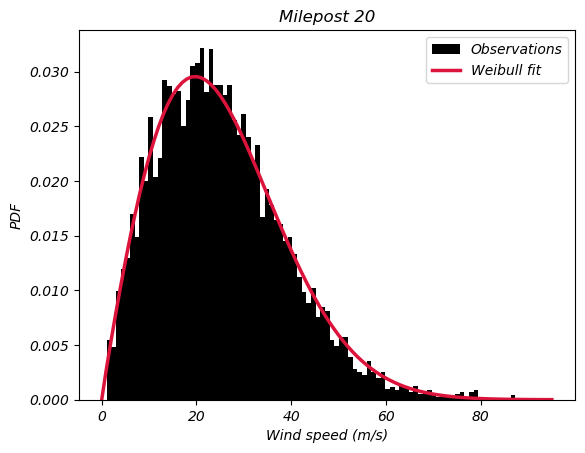

In [20]:
mp_to_plot = 'MP20'

data = dict_occur[mp_to_plot][18]['Gradient Wind speed'].astype(float).to_numpy()

max_val = ceil(data.max())
counts, bins = np.histogram(data, bins = max_val,density = True)

shape,loc,scale = weibull_min.fit(data,floc=0)
x = np.arange(0,max_val)
y_i = (x-loc)/scale
y1 = weibull_min.pdf(y_i,shape)/scale    

plt.stairs(counts,bins, fill = True, label = 'Observations', color = 'black')
plt.plot(x,y1,linewidth=2.5, color = 'crimson',label = 'Weibull fit')

plt.title('Milepost 20')
plt.ylabel('PDF')
plt.xlabel('Wind speed (m/s)')
plt.legend()

## Plotting all mileposts

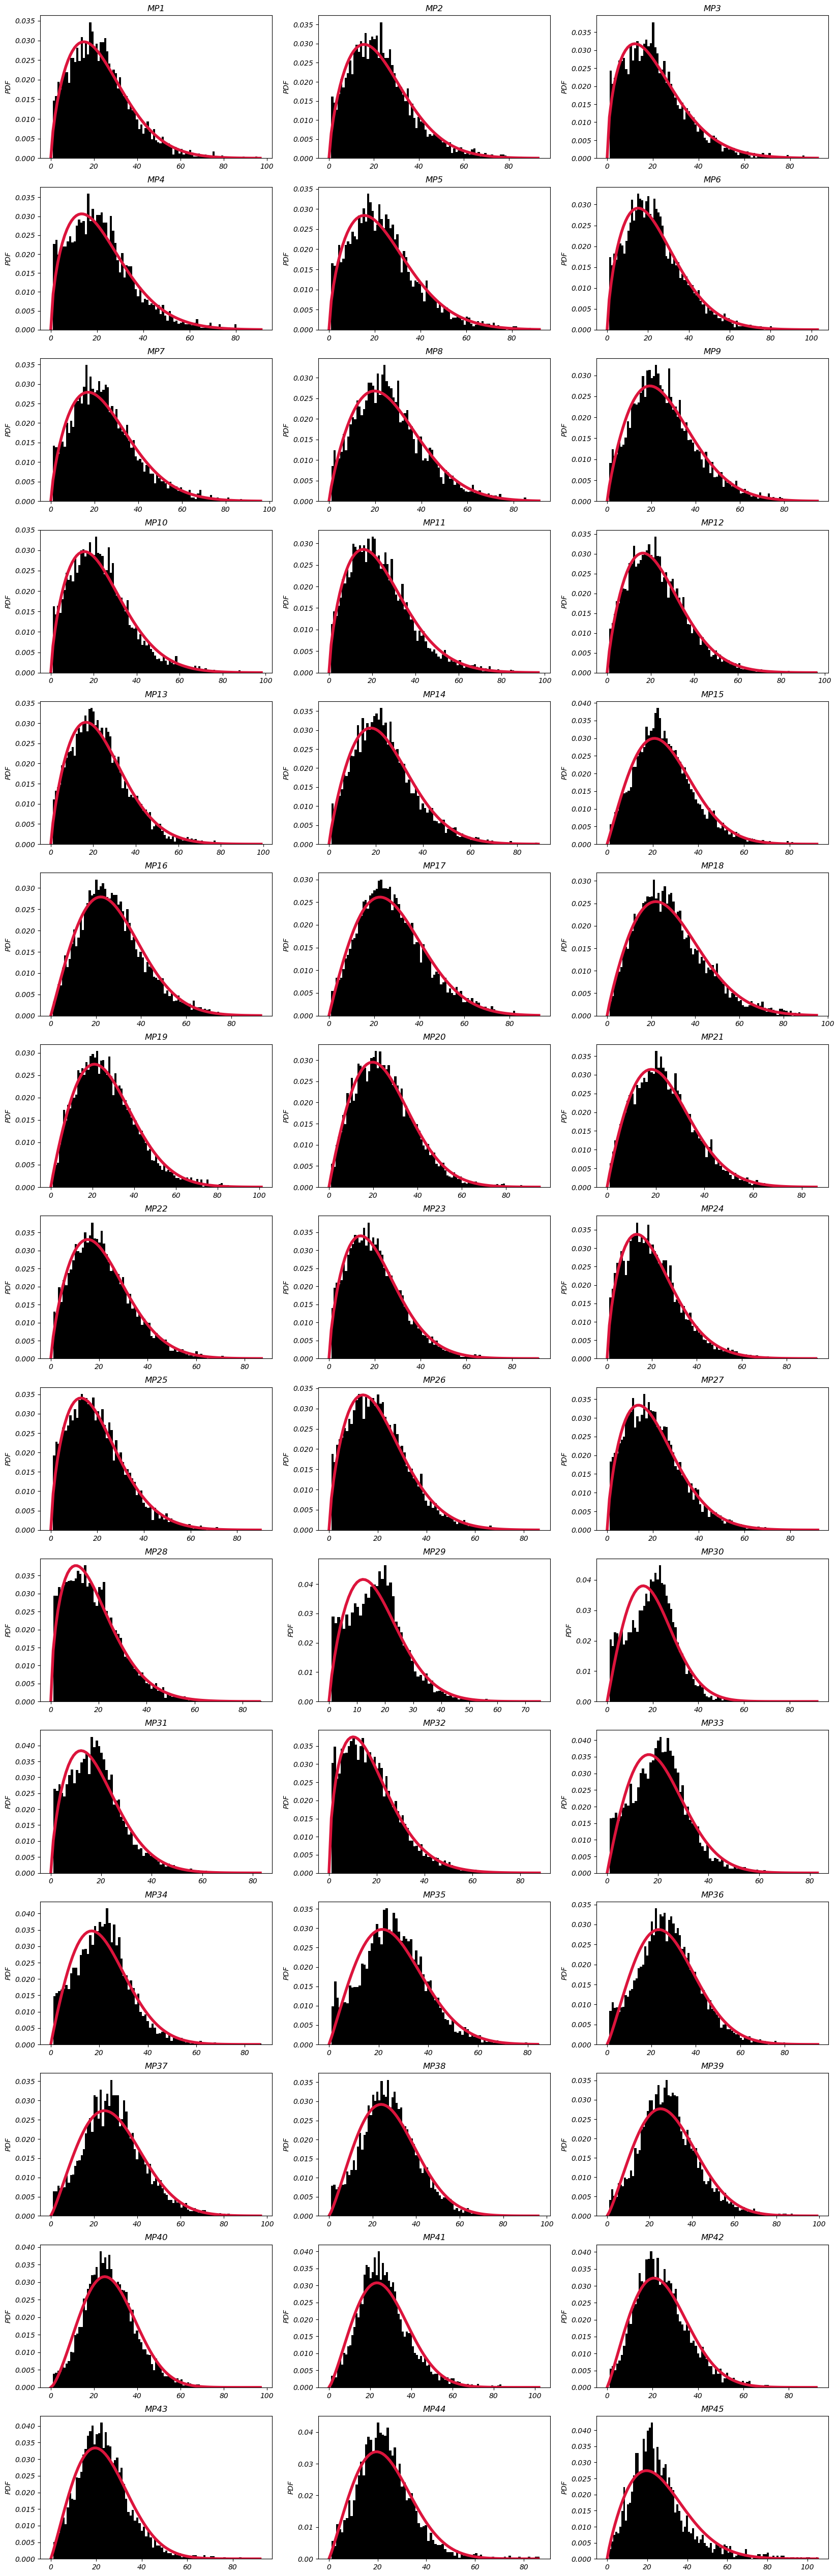

In [21]:
binned_hurrs = []
weib_params = []

for mp_to_plot in dict_occur.keys() : 

    data = dict_occur[mp_to_plot][18]['Gradient Wind speed'].astype(float).to_numpy()
    max_val = ceil(data.max())
    
    counts, bins = np.histogram(data , bins = max_val,density = True)   
    binned_hurrs.append((counts,bins,mp_to_plot))    
    
    shape,loc,scale = weibull_min.fit(data,floc=0)     

    weib_params.append((shape,loc,scale))
    
    try :
        dict_occur[mp_to_plot][20] = (shape,loc,scale)
    except : 
    # If absent, add to the list :
        dict_occur[mp_to_plot].insert(20,(shape,loc,scale))  
    
    
fig, axs = plt.subplots(15, 3, figsize=(20, 65))
i =0
for ax, ele in zip(axs.flat,binned_hurrs) :
    
    ax.stairs(ele[0],ele[1], fill = True, color = 'black')    

    shape1 = weib_params[i][0] 
    loc1 = weib_params[i][1]
    scale1 = weib_params[i][2]
    
    x = np.arange(0,ele[1].max())
    y_i = (x-loc1)/scale1
    y1 = weibull_min.pdf(y_i,shape1)/scale1    

    ax.plot(x,y1,linewidth=4, color = 'crimson')
    
    ax.set_title(f'{ele[2]}')
    ax.set_ylabel('PDF')
    i+=1   

# Plot annual Surface wind speed maxima

## Plotting an individual milepost

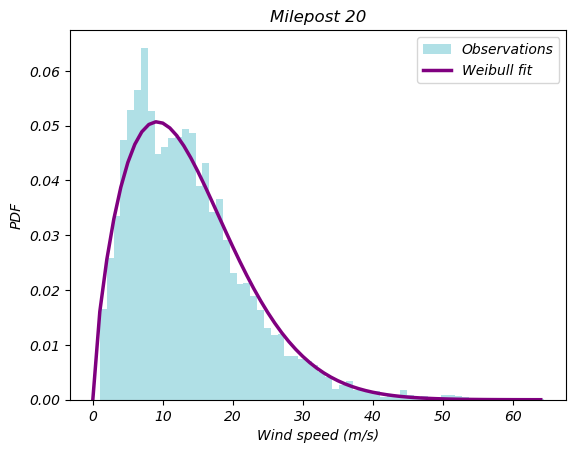

In [22]:
mp_to_plot = 'MP20'

data = dict_occur[mp_to_plot][19]['Surface Wind speed'].astype(float).to_numpy()

max_val = ceil(data.max())
counts, bins = np.histogram(data, bins = max_val,density = True)

shape,loc,scale = weibull_min.fit(data,floc=0)
x = np.arange(0,max_val)
y_i = (x-loc)/scale
y1 = weibull_min.pdf(y_i,shape)/scale    

plt.stairs(counts,bins, fill = True, label = 'Observations', color = 'Powderblue')
plt.plot(x,y1,linewidth=2.5, color = 'purple',label = 'Weibull fit')

plt.title('Milepost 20')
plt.ylabel('PDF')
plt.xlabel('Wind speed (m/s)')
plt.legend()

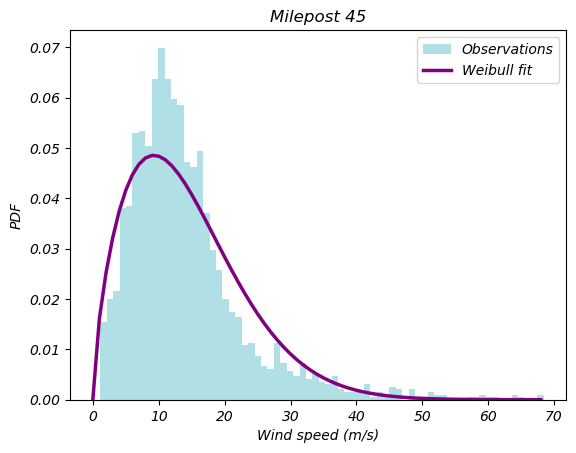

In [23]:
from scipy.stats import gumbel_l,weibull_max, invweibull,lognorm,genpareto,gumbel_r

mp_to_plot = 'MP45'

data = dict_occur[mp_to_plot][19]['Surface Wind speed'].astype(float).to_numpy()
max_val = ceil(data.max())

counts, bins = np.histogram(data, bins = max_val,density = True)
shape,loc,scale = weibull_min.fit(data,floc=0)

x = np.arange(0,max_val)
y_i = (x-loc)/scale
y1 = weibull_min.pdf(y_i,shape)/scale      

plt.stairs(counts,bins, fill = True, label = 'Observations', color = 'Powderblue')
plt.plot(x,y1,linewidth=2.5, color = 'purple',label = 'Weibull fit')

plt.title('Milepost 45')
plt.ylabel('PDF')
plt.xlabel('Wind speed (m/s)')
plt.legend()

## Plotting all mileposts

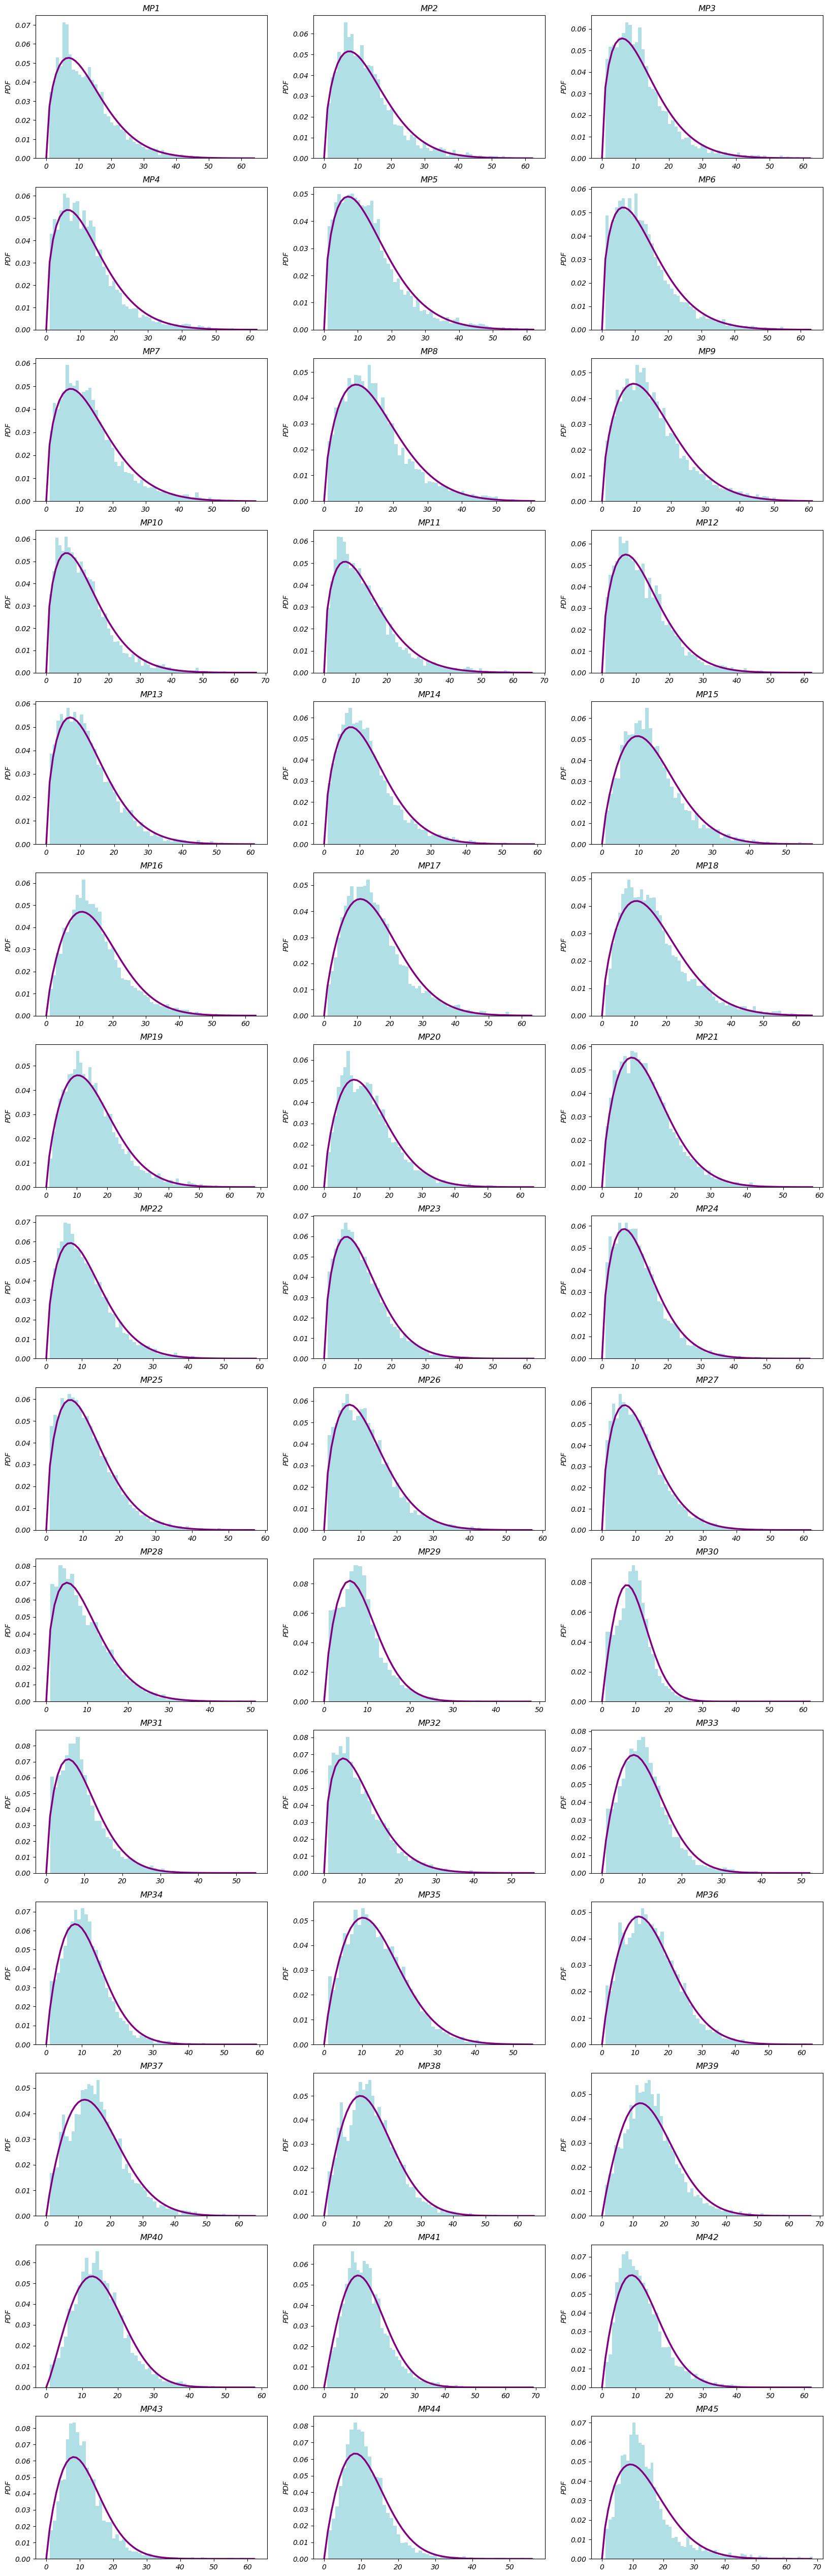

In [24]:
binned_hurrs = []
weib_params = []

for mp_to_plot in dict_occur.keys() : 

    data = dict_occur[mp_to_plot][19]['Surface Wind speed'].astype(float).to_numpy()
    max_val = ceil(data.max())
    
    counts, bins = np.histogram(data , bins = max_val,density = True)   
    binned_hurrs.append((counts,bins,mp_to_plot))    
    
    shape,loc,scale = weibull_min.fit(data,floc=0)  

    weib_params.append((shape,loc,scale))
    
    try :
        dict_occur[mp_to_plot][21] = (shape,loc,scale)
    except : 
    # If absent, add to the list :
        dict_occur[mp_to_plot].insert(21,(shape,loc,scale))
    
    
fig, axs = plt.subplots(15, 3, figsize=(20, 65))
i =0
for ax, ele in zip(axs.flat,binned_hurrs) :
    
    
    ax.stairs(ele[0],ele[1], fill = True, color = 'Powderblue')    

    shape1 = weib_params[i][0] 
    loc1 = weib_params[i][1]
    scale1 = weib_params[i][2]
    
    x = np.arange(0,ele[1].max())
    y_i = (x-loc1)/scale1
    y1 = weibull_min.pdf(y_i,shape1)/scale1    
   
    ax.plot(x,y1,linewidth=2.5, color = 'purple')  
    ax.set_title(f'{ele[2]}')
    ax.set_ylabel('PDF')
    
    i+=1    

    

## Discretized hazard curves

In [31]:
# Pick a range from which to assess the hazard : 
bounds_KMpH = np.array([60,250]) # Wind speed (intensity measure) bounds to investigate, in km/h

# Pick an amount of samples to assess :
n_samples = 18 # Number of desired MRIs to compute. FEMA P58 typically requests at least 8.
sample_edges, step = np.linspace(bounds_KMpH[0],bounds_KMpH[1],n_samples+1,retstep=True)

# Define the midpoint values for each segment : 
sample_midpoints = (sample_edges + step/2)[:-1]  # Shift from edges to midpoints, ignore last edge (no overshoot)

# Find the probability weights to associate with each segment
MRI_midpoints_and_weights = []

discretized_mp = pd.DataFrame()
for mp_to_plot in dict_occur.keys(): 
        shape,loc,scale = dict_occur[mp_to_plot][21]
        relevant_lf_data = dict_occur[mp_to_plot][17]
        relevant_lf_data = relevant_lf_data[relevant_lf_data['Surface Wind speed']*1.4>9]
        lamb = relevant_lf_data.shape[0]/max_year_sim
        
        # Recall, distribution numbers are in meter per second : 
        sample_edges_MpS = sample_edges*1000/3600
        sample_midpoints_MpS = sample_midpoints*1000/3600

        # For each value, find how far along the CDF these wind speeds are :  
        edge_cdfs = stats.weibull_min.cdf(sample_edges_MpS,shape,loc,scale)
        midpoint_cdfs = stats.weibull_min.cdf(sample_midpoints_MpS,shape,loc,scale)
        
        # Add consideration for the hurricane occurences:
            # Relative to Mean recurrence intervals:
        midpoints_MRIs = np.round(1/(1-np.exp(-lamb*(1-midpoint_cdfs))),decimals = 0)
            # Relative to interval probabilities:
            
        # Correction for the final point : it represents all the way to infinity :
        edge_cdfs[-1] = 1     
        
        edge_true_cdfs = 1-np.exp(-lamb*(1-edge_cdfs))       
        edge_cdfs = edge_true_cdfs

    
        # Identify the Mean recurrence intervall to which it corresponds :        
        
        # Notice, no correction is made for index 0 (representing an im=0), as the contribution before
        # the first bound should all be zero (no damages). 

        # Get the delta between points : 
        sample_delta_probabilities = np.diff(edge_cdfs)*(-1)
            
        # Store these values :
        idx = pd.MultiIndex.from_product([[mp_to_plot],['Midpoint MRI','3 Second Gust Midpoint Wind speed (miles per hr)','delta_lambda']])
        MRI_midpoints_and_weights = pd.DataFrame([midpoints_MRIs,sample_midpoints/1.60934*1.39,sample_delta_probabilities],idx)#.T
                
        discretized_mp = pd.concat([discretized_mp,MRI_midpoints_and_weights])

# Note : all winds speeds will be the same, but not the Midpoint MRI (thus, not the delta_lambda either).
display(discretized_mp.T)
     
# Export everything? 
to_export = True 
if to_export == True : 
    discretized_mp.T.to_excel('Discretized_mp_v4.xlsx')

MP1                                                                 
   Midpoint MRI 3 Second Gust Midpoint Wind speed (miles per hr) delta_lambda   
0          12.0                                        56.380946     0.027340  \
1          18.0                                        65.497865     0.020975   
2          26.0                                        74.614783     0.015405   
3          39.0                                        83.731702     0.010889   
4          61.0                                        92.848621     0.007439   
5          97.0                                       101.965540     0.004929   
6         158.0                                       111.082459     0.003176   
7         262.0                                       120.199378     0.001995   
8         443.0                                       129.316297     0.001224   
9         766.0                                       138.433216     0.000734   
10       1348.0                                       147.550134     0.000431   
11       2416.0                                       156.667053     0.000248   
12       4408.0                                       165.783972     0.000140   
13       8178.0                                       174.900891     0.000078   
14      15425.0                                       184.017810     0.000042   
15      29568.0                                       193.134729     0.000023   
16      57573.0                                       202.251648     0.000012   
17     113836.0                                       211.368567     0.000012   

            MP2                                                                 
   Midpoint MRI 3 Second Gust Midpoint Wind speed (miles per hr) delta_lambda   
0          11.0                                        56.380946     0.031006  \
1          15.0                                        65.497865     0.024096   
2          22.0                                        74.614783     0.017853   
3          34.0                                        83.731702     0.012680   
4          53.0                                        92.848621     0.008673   
5          85.0                                       101.965540     0.005735   
6         139.0                                       111.082459     0.003676   
7         234.0                                       120.199378     0.002291   
8         402.0                                       129.316297     0.001390   
9         706.0                                       138.433216     0.000822   
10       1267.0                                       147.550134     0.000475   
11       2321.0                                       156.667053     0.000269   
12       4337.0                                       165.783972     0.000148   
13       8261.0                                       174.900891     0.000080   
14      16032.0                                       184.017810     0.000043   
15      31691.0                                       193.134729     0.000022   
16      63777.0                                       202.251648     0.000011   
17     130627.0                                       211.368567     0.000011   

            MP3                                                                 
   Midpoint MRI 3 Second Gust Midpoint Wind speed (miles per hr) delta_lambda   
0          14.0                                        56.380946     0.025344  \
1          20.0                                        65.497865     0.018970   
2          30.0                                        74.614783     0.013631   
3          47.0                                        83.731702     0.009454   
4          73.0                                        92.848621     0.006354   
5         117.0                                       101.965540     0.004153   
6         191.0                                       111.082459     0.002647   
7         319.0                          

## Wind speeds per MRI

In [32]:
# List the MRI of interest : 
MRI_values = [10,25,50,100,250,300,500,700,1000,1700,2000,3000]
#MRI_values = [50,250,500,1000,2000]

# Identify the values according to the fitted distributions : 
for mp_to_plot in dict_occur.keys() :
    shape,loc,scale = dict_occur[mp_to_plot][21] 
    wind_speeds_mph = []

    relevant_lf_data = dict_occur[mp_to_plot][17]
    relevant_lf_data = relevant_lf_data[relevant_lf_data['Surface Wind speed']*1.4>9]
    lamb = relevant_lf_data.shape[0]/max_year_sim   
    
    for MRI in MRI_values :  

        Y = -np.log(1-1/MRI)/lamb
        dp = 1-Y

        Wind_MRI = stats.weibull_min.ppf(dp,shape,loc,scale)       
        Wind_MRI_mph = Wind_MRI*(3600/1609.34)
        
        wind_speeds_mph.append([MRI,Wind_MRI_mph])
    
    MRI_df = pd.DataFrame(wind_speeds_mph,columns = ['MRI','Wind speeds (mph)'])

    
    # Store the info per Milepost : 
    try :
        dict_occur[mp_to_plot][22] = MRI_df
    except : 
    # If absent, add to the list :
        dict_occur[mp_to_plot].insert(22,MRI_df)

# Plot the MRI values per mileposts (3 sec gust)

In [33]:
# Generate a summary of all MRIs, per location : 
MRI_summary = pd.DataFrame()

for mp in mileposts_ids : 
    mp_id = mp+1
    mp_dict = f'MP{mp_id}'
    
    wind_MRIs = dict_occur[mp_dict][22].T.loc['Wind speeds (mph)']
    wind_MRIs = wind_MRIs.rename(f'MP{mp_id}')
    MRI_summary = pd.concat([MRI_summary,wind_MRIs*1.4],axis = 1)
    
MRI_summary = MRI_summary.T
MRI_summary.columns = MRI_values
display(MRI_summary)

,10,25,50,100,250,300,500,700,1000,1700,2000,3000
MP1,50.749820,74.235121,89.424152,103.304747,120.262021,123.486662,132.299967,137.943498,143.799898,152.295060,154.848877,161.129463
MP2,54.736116,77.592993,92.354428,105.817085,122.225075,125.340393,133.847057,139.288270,144.929885,153.104898,155.560519,161.595846
MP3,47.570183,70.729886,85.831221,99.701826,116.726118,119.972488,128.858804,134.559138,140.482410,149.088321,151.678503,158.054357
MP4,51.141120,74.501077,89.753920,103.764017,120.953642,124.230496,133.198297,138.949319,144.923902,153.601842,156.213112,162.639699
MP5,60.360414,85.042563,101.273446,116.223189,134.598538,138.104285,147.701968,153.859166,160.257214,169.552436,172.349876,179.235340
MP6,57.426793,81.081721,96.724810,111.180474,129.000421,132.405985,141.738061,147.731221,153.963795,163.027209,165.756798,172.478877
MP7,66.510846,89.993197,105.552287,119.924626,137.621075,140.999755,150.252226,156.189518,162.359954,171.325551,174.023939,180.665728
MP8,77.722432,100.387069,115.333037,129.075751,145.910602,149.114026,157.869227,163.474253,169.288676,177.717956,180.250595,186.476037
MP9,78.418968,100.579457,115.237089,128.735072,145.289692,148.441770,157.059377,162.578236,168.304700,176.608812,179.104345,185.239488
MP10,60.025919,81.889543,96.416673,109.861700,126.447485,129.617758,138.305155,143.884059,149.685397,158.120595,160.660675,166.915346


In [239]:
# Get a table linking latitude/longitude with MRIs
MP_MRIs = mileposts.copy()
MRI_summaryb = MRI_summary.copy().reset_index()
MP_MRIs = pd.concat([MP_MRIs,MRI_summaryb],axis = 1,ignore_index = False)
MP_MRIs = MP_MRIs.set_index('index')
display(MP_MRIs)

# Export everything? 
to_export = True 
if to_export == True : 
    MP_MRIs.to_excel('MP_MRIs_v3.xlsx')

,Lat,Long,10,25,50,100,250,300,500,700,1000,1700,2000,3000
index,,,,,,,,,,,,,,
MP1,25.000000,-97.524595,50.749820,74.235121,89.424152,103.304747,120.262021,123.486662,132.299967,137.943498,143.799898,152.295060,154.848877,161.129463
MP2,25.685860,-97.222046,54.736116,77.592993,92.354428,105.817085,122.225075,125.340393,133.847057,139.288270,144.929885,153.104898,155.560519,161.595846
MP3,27.091478,-97.374228,47.570183,70.729886,85.831221,99.701826,116.726118,119.972488,128.858804,134.559138,140.482410,149.088321,151.678503,158.054357
MP4,28.300761,-96.601763,51.141120,74.501077,89.753920,103.764017,120.953642,124.230496,133.198297,138.949319,144.923902,153.601842,156.213112,162.639699
MP5,29.048657,-95.223012,60.360414,85.042563,101.273446,116.223189,134.598538,138.104285,147.701968,153.859166,160.257214,169.552436,172.349876,179.235340
MP6,29.718147,-93.809895,57.426793,81.081721,96.724810,111.180474,129.000421,132.405985,141.738061,147.731221,153.963795,163.027209,165.756798,172.478877
MP7,29.594504,-92.210557,66.510846,89.993197,105.552287,119.924626,137.621075,140.999755,150.252226,156.189518,162.359954,171.325551,174.023939,180.665728
MP8,29.144394,-90.772443,77.722432,100.387069,115.333037,129.075751,145.910602,149.114026,157.869227,163.474253,169.288676,177.717956,180.250595,186.476037
MP9,29.260755,-89.261702,78.418968,100.579457,115.237089,128.735072,145.289692,148.441770,157.059377,162.578236,168.304700,176.608812,179.104345,185.239488


## Plot for a single milepost

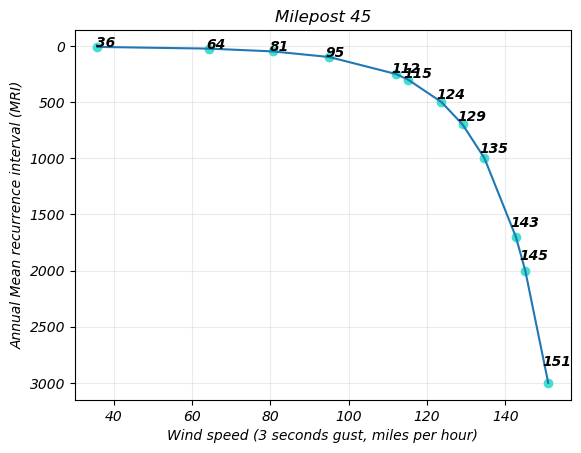

In [240]:
mp_to_plot = 'MP45'


x = MRI_values
y = MRI_summary.loc[mp_to_plot].to_numpy()#*1.39

fig = plt.figure()
ax = plt.axes()
plt.plot(y,x)
plt.scatter(y,x,color = 'turquoise')

for i in range(len(MRI_values)) :
    plt.text(y[i]*(1-0.01), x[i]*(1-0.05) , f'{y[i]:.0f}',weight = 'bold')

ax.invert_yaxis()
plt.title('Milepost 45')
plt.xlabel('Wind speed (3 seconds gust, miles per hour)')
plt.ylabel('Annual Mean recurrence interval (MRI)')

plt.grid(alpha = 0.25)

## Plot for all mileposts

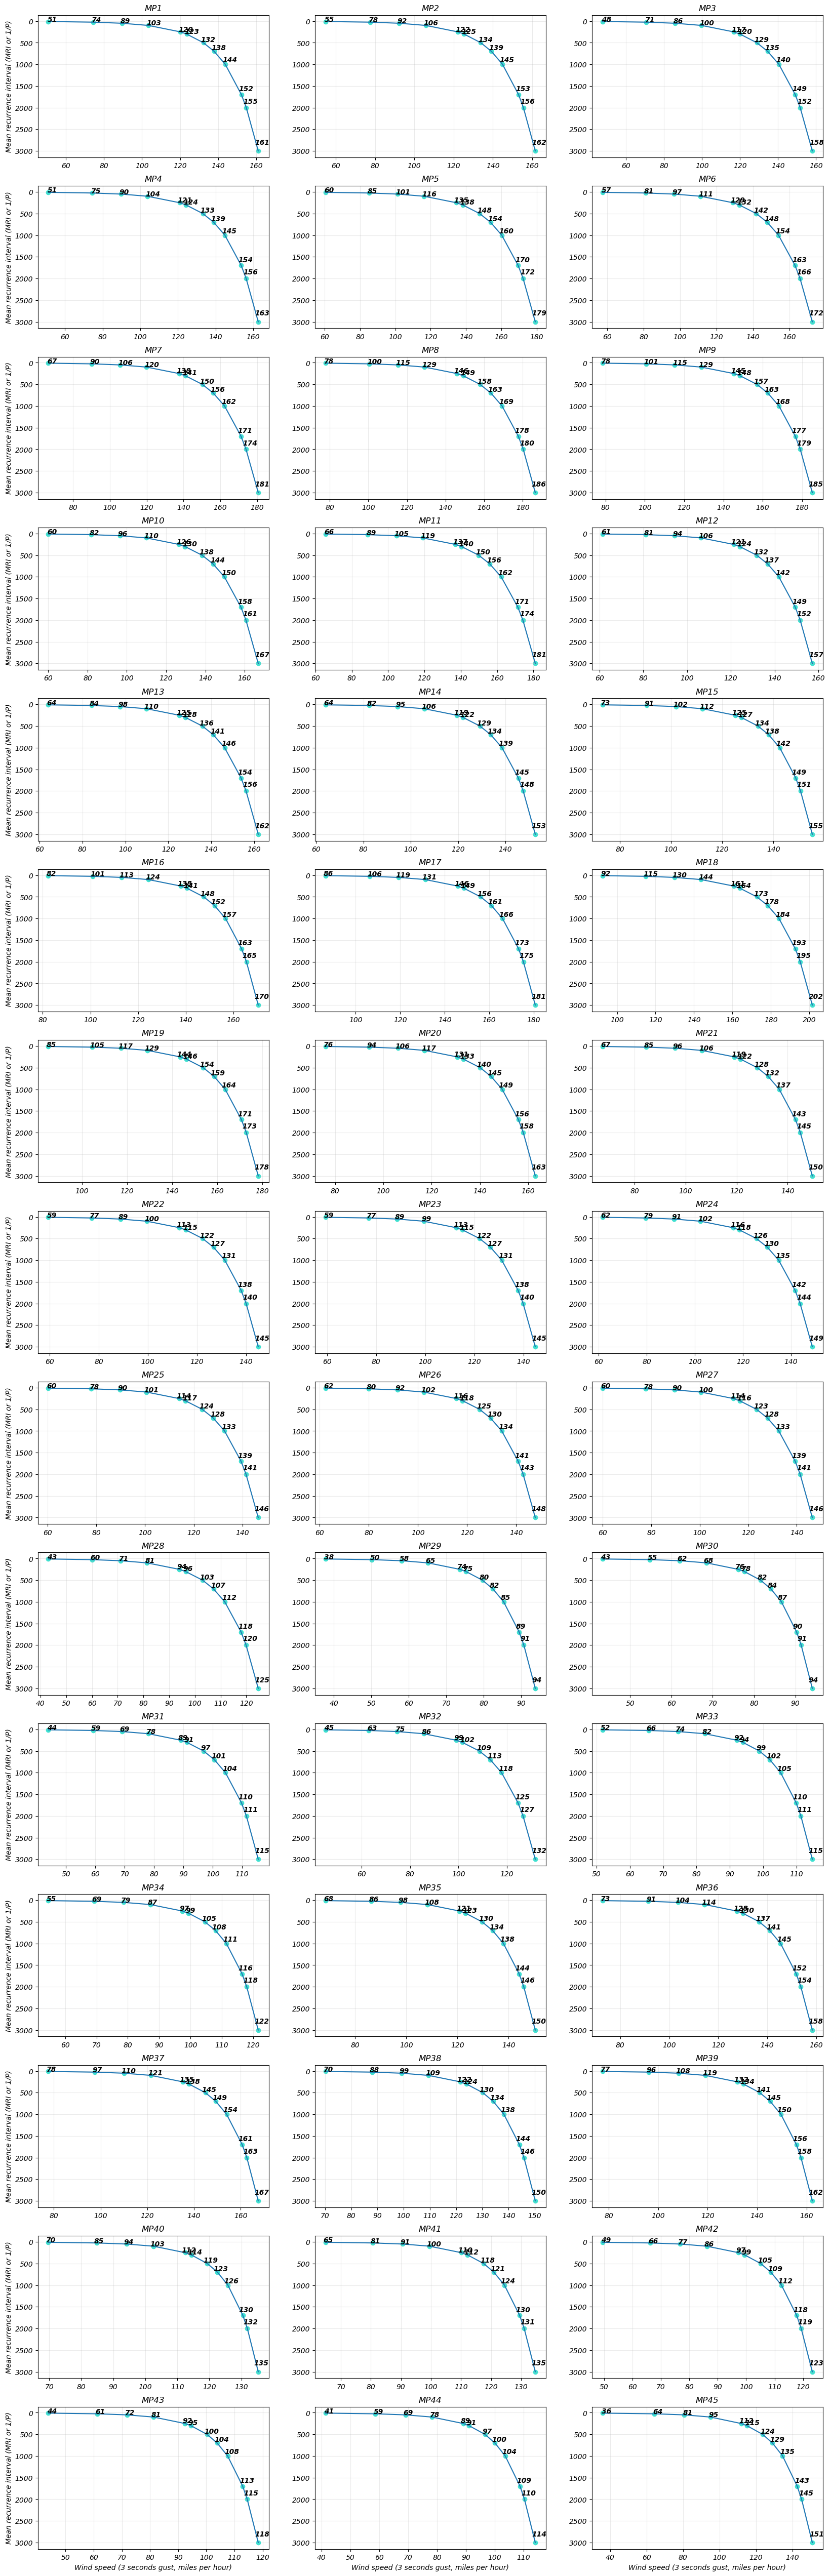

In [241]:
n_rows = 15
n_cols = 3

fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 65))
k=1
x = MRI_values
for ax in axs.flat : 
    MP_to_plot = str(f'MP{k}')
    
    y = MRI_summary.loc[MP_to_plot].to_numpy()
    ax.plot(y,x)
    ax.scatter(y,x,color = 'turquoise')    
    
    for i in range(len(MRI_values)) :
        ax.text(y[i]*(1-0.01), x[i]*(1-0.05) , f'{y[i]:.0f}',weight = 'bold')
    
    ax.invert_yaxis()    
    ax.set_title(MP_to_plot)
    
    if (k-1) %3 == 0 : 
        ax.set_ylabel('Mean recurrence interval (MRI or 1/P)')
    if k > (n_rows*n_cols-n_cols) :
        ax.set_xlabel('Wind speed (3 seconds gust, miles per hour)')

    ax.grid(alpha = 0.25)
    
    
    k+=1    

## Generate an overview

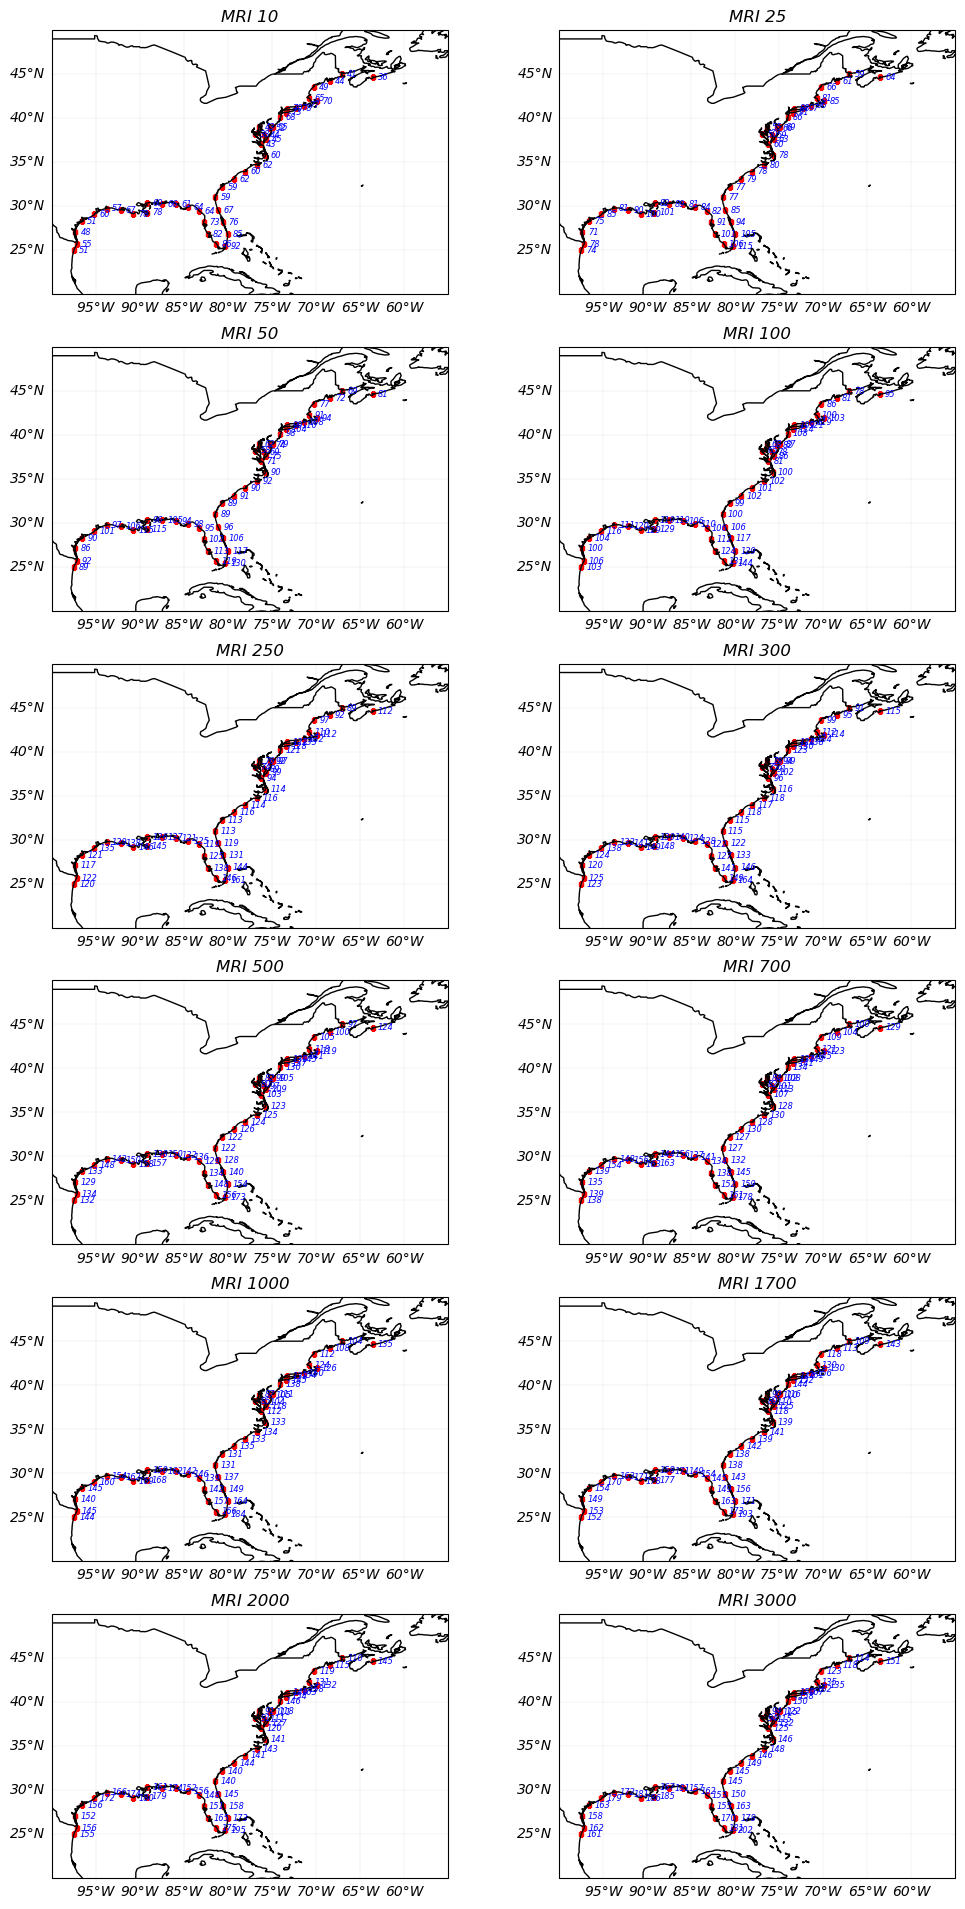

In [242]:
# Plot all MRIs for all mileposts : 
fig, axs = plt.subplots(6, 2, figsize=(12, 24), subplot_kw={'projection':ccrs.PlateCarree()})
k=0
for ax in axs.flat : 
    ax.set_extent([-100, -55, 20, 50], crs = ccrs.PlateCarree()) 
    ax.scatter(MP_MRIs['Long'], MP_MRIs['Lat'], color='red', s=10, marker = 's')
    gl = ax.gridlines(xlocs = -long_range, ylocs = lat_range, draw_labels=True,linewidth=0.1)
    gl.top_labels = False
    gl.right_labels = False
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    
    for row in MP_MRIs.iterrows() : 
        ax.text(row[1]['Long']+0.6, row[1]['Lat']-0.3,f'{row[1][MRI_values[k]]:.0f}',transform=ccrs.PlateCarree(),size = 6, color = 'b')    
    
    ax.set_title(f'MRI {MRI_values[k]}')
    k+=1  